# DATATÓN 3 – Deep Learning + Streamlit
### Fashion MNIST: Clasificación de Prendas de Ropa

---

## 1. Portada e Integrantes

**Equipo:** Grupo 7 – Fashion Classifiers

| Integrante | Código |
|---|---|
| Ivan Enrique Gonzalez Paredes | xxxxxxxx |
| Elizabeth Antuaneth Suarez Pazos | xxxxxxxx |
| Stephany Gutierrez | xxxxxxxx |
| Raquel Melany Mendoza Tello | xxxxxxxx |

> **Antes de ejecutar:** Activa la GPU en Google Colab
> 
> Entorno de ejecucion → Cambiar tipo de entorno de ejecucion → Acelerador de hardware → GPU
> 
> Luego ejecuta todo: Entorno de ejecucion → Ejecutar todo

In [1]:
# ─── Semillas para reproducibilidad ───────────────────────────────────────────
import numpy as np
import tensorflow as tf
import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# ─── Imports generales ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score, f1_score)

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Flatten, Conv2D, MaxPooling2D,
    Dropout, BatchNormalization, GlobalAveragePooling2D,
    RandomFlip, RandomRotation, RandomZoom, RandomTranslation
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

print("TensorFlow version:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

---
## 2. Exploración y Preparación de Datos (EDA)

In [2]:
# ─── 2.1 Carga del dataset ────────────────────────────────────────────────────
(X_train_raw, y_train), (X_test_raw, y_test) = fashion_mnist.load_data()

CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print(f'X_train shape: {X_train_raw.shape}  |  y_train shape: {y_train.shape}')
print(f'X_test shape:  {X_test_raw.shape}   |  y_test shape:  {y_test.shape}')
print(f'Rango de píxeles original → min: {X_train_raw.min()}, max: {X_train_raw.max()}')

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
X_train shape: (60000, 28, 28)  |  y_train shape: (60000,)
X_test shape:  (10000, 28, 28)   |  y_test shape:  (10000,)
Rango de píxeles original → min: 0, max: 255


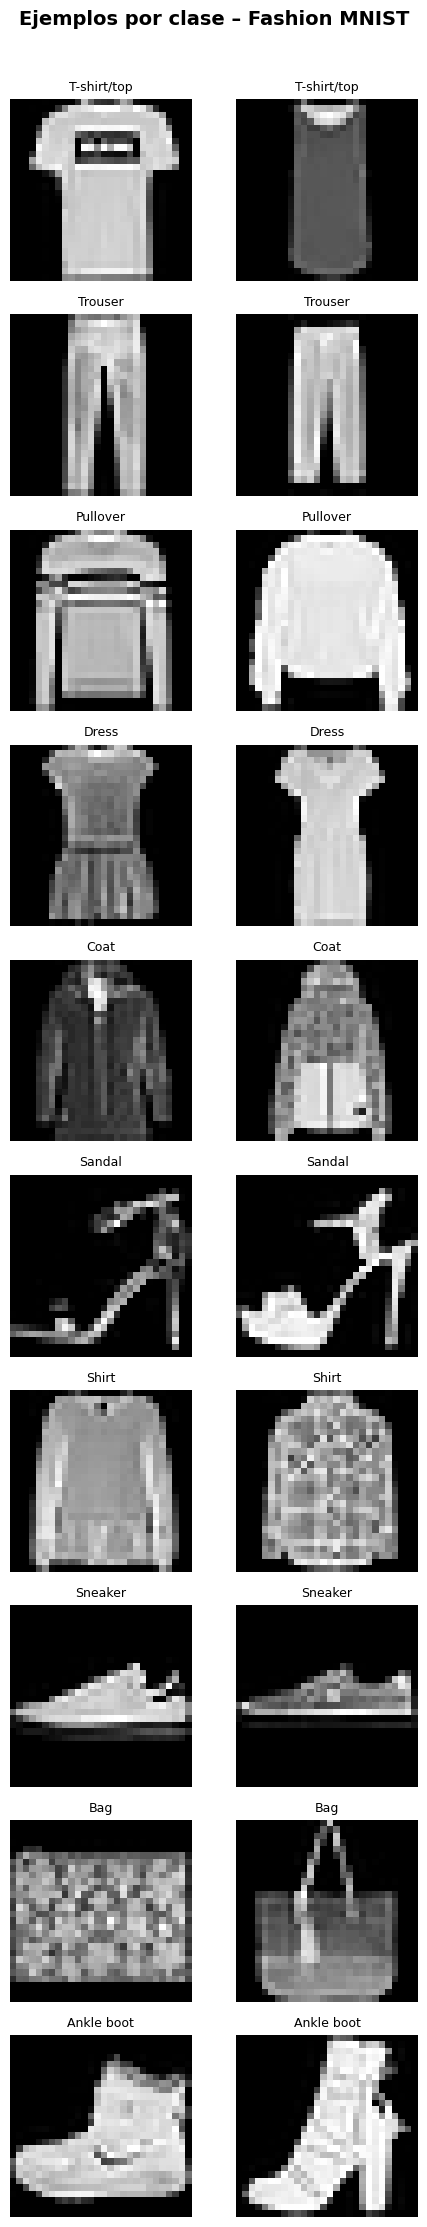

In [3]:
# ─── 2.2 Visualización: 2 imágenes por clase ──────────────────────────────────
fig, axes = plt.subplots(10, 2, figsize=(5, 22))
fig.suptitle('Ejemplos por clase – Fashion MNIST', fontsize=14, fontweight='bold', y=1.01)

for class_id in range(10):
    indices = np.where(y_train == class_id)[0][:2]
    for col, idx in enumerate(indices):
        ax = axes[class_id][col]
        ax.imshow(X_train_raw[idx], cmap='gray')
        ax.set_title(CLASS_NAMES[class_id], fontsize=9)
        ax.axis('off')

plt.tight_layout()
plt.savefig('samples_por_clase.png', bbox_inches='tight', dpi=120)
plt.show()

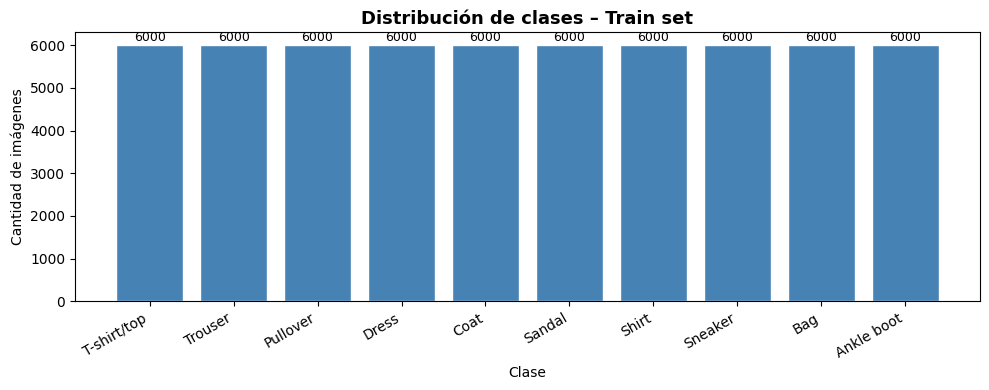


Conteo por clase:
{'T-shirt/top': np.int64(6000), 'Trouser': np.int64(6000), 'Pullover': np.int64(6000), 'Dress': np.int64(6000), 'Coat': np.int64(6000), 'Sandal': np.int64(6000), 'Shirt': np.int64(6000), 'Sneaker': np.int64(6000), 'Bag': np.int64(6000), 'Ankle boot': np.int64(6000)}


In [4]:
# ─── 2.3 Distribución de clases ───────────────────────────────────────────────
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10, 4))
bars = plt.bar([CLASS_NAMES[i] for i in unique], counts, color='steelblue', edgecolor='white')
plt.title('Distribución de clases – Train set', fontsize=13, fontweight='bold')
plt.xlabel('Clase')
plt.ylabel('Cantidad de imágenes')
plt.xticks(rotation=30, ha='right')
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, str(count), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('distribucion_clases.png', bbox_inches='tight', dpi=120)
plt.show()

print(f'\nConteo por clase:\n{dict(zip(CLASS_NAMES, counts))}')

**📊 Análisis – Distribución de clases:**

El dataset Fashion MNIST está perfectamente balanceado: cada una de las 10 clases contiene exactamente **6,000 imágenes** en el conjunto de entrenamiento (60,000 total) y **1,000** en el conjunto de test (10,000 total). Por tanto, **no existe desbalance de clases**, lo que simplifica el entrenamiento y hace que accuracy sea una métrica representativa del rendimiento global.

In [5]:
# ─── 2.4 Normalización y reshape ──────────────────────────────────────────────

# Normalización al rango [0, 1]
X_train_norm = X_train_raw / 255.0
X_test_norm  = X_test_raw  / 255.0

# Para MLP: aplanar a vector 1D (784 píxeles)
X_train_mlp = X_train_norm.reshape(-1, 784)
X_test_mlp  = X_test_norm.reshape(-1, 784)

# Para CNN: agregar canal de color → (28, 28, 1)
X_train_cnn = X_train_norm.reshape(-1, 28, 28, 1)
X_test_cnn  = X_test_norm.reshape(-1, 28, 28, 1)

print('Shapes para MLP  → train:', X_train_mlp.shape, '| test:', X_test_mlp.shape)
print('Shapes para CNN  → train:', X_train_cnn.shape, '| test:', X_test_cnn.shape)
print(f'Rango normalizado → min: {X_train_norm.min():.2f}, max: {X_train_norm.max():.2f}')

Shapes para MLP  → train: (60000, 784) | test: (10000, 784)
Shapes para CNN  → train: (60000, 28, 28, 1) | test: (10000, 28, 28, 1)
Rango normalizado → min: 0.00, max: 1.00


**📊 Análisis – Normalización:**

Dividir los valores de píxeles entre 255 lleva los datos del rango `[0, 255]` al rango `[0, 1]`. Esto es importante por tres razones:
1. **Estabilidad numérica:** el descenso por gradiente converge más rápido cuando las entradas tienen magnitudes similares y pequeñas.
2. **Funciones de activación:** ReLU y Sigmoid/Softmax trabajan mejor con valores acotados.
3. **Inicialización de pesos:** los pesos iniciales típicamente son pequeños; sin normalización, las activaciones iniciales pueden ser enormes, causando gradientes explosivos.

**📊 Análisis – Clases difíciles de distinguir visualmente:**

- **Shirt (6) vs Pullover (2) vs Coat (4):** Las tres son prendas de torso con siluetas similares. Se diferencian principalmente en el cuello y los bordes, detalles sutiles en 28×28 píxeles.
- **Sneaker (7) vs Ankle boot (9):** Ambos son calzado cerrado; la diferencia es el caño del boot, que puede ser poco visible en imágenes pequeñas.
- **T-shirt/top (0) vs Dress (3):** A veces el largo de la prenda es el único discriminador y puede perderse con el recorte de la imagen.

---
## 3. Modelo 1 – MLP (Baseline)

### 📋 Decisión de arquitectura e hiperparámetros – MLP Baseline

Siguiendo la metodología de clase, documentamos la justificación de cada hiperparámetro:

| Parámetro | Valor elegido | Justificación |
|---|---|---|
| `hidden_layer_sizes` | 512 → 256 → 128 | **Arquitectura en embudo**: capas que comprimen la representación progresivamente. 512 neuronas en la primera capa capturan la variedad de los 784 píxeles; cada capa extrae representaciones más abstractas y compactas. |
| `activation` | `relu` | Estándar moderno: evita el *vanishing gradient* de sigmoid/tanh. `relu(x) = max(0,x)` no satura en valores positivos → el gradiente fluye limpiamente hacia capas anteriores. |
| `optimizer` | `adam` | Optimizador adaptativo (AdaGrad + RMSProp): ajusta la tasa de aprendizaje individualmente por parámetro. No requiere tuning manual de momentum — ideal para un baseline robusto. |
| `loss` | `sparse_categorical_crossentropy` | Clasificación multiclase con etiquetas enteras 0–9. Equivalente a `categorical_crossentropy` pero sin necesidad de one-hot encoding — más eficiente en memoria. |
| `batch_size` | 128 | Balance velocidad/estabilidad: lotes de 32–64 dan más ruido (mejor generalización pero más lento); lotes de 512+ convergen a mínimos peores. 128 es el punto medio recomendado. |
| `epochs` | 15 | Suficiente para estabilizar las curvas de validación sin overfitting severo. Se verificó visualmente con las curvas de loss y accuracy. |
| `validation_split` | 0.1 | 10% del train reservado para monitorear overfitting en tiempo real, sin contaminar el test set. |

> **Limitación de diseño:** el MLP aplana la imagen (28×28 → 784 píxeles) perdiendo completamente la estructura espacial 2D. Una prenda desplazada 3 píxeles aparece como una entrada totalmente distinta. Las CNN resuelven esto con filtros locales de 3×3 con pesos compartidos.

In [6]:
# ─── 3.1 Definir arquitectura MLP ─────────────────────────────────────────────
mlp = Sequential([
    Dense(512, activation='relu', input_shape=(784,)),   # Capa oculta 1
    Dense(256, activation='relu'),                        # Capa oculta 2
    Dense(128, activation='relu'),                        # Capa oculta 3
    Dense(10,  activation='softmax')                      # Capa de salida
], name='MLP_Baseline')

mlp.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

mlp.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "MLP_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# ─── 3.2 Entrenamiento MLP ────────────────────────────────────────────────────
history_mlp = mlp.fit(
    X_train_mlp, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8210 - loss: 0.5055 - val_accuracy: 0.8582 - val_loss: 0.3941
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8659 - loss: 0.3648 - val_accuracy: 0.8688 - val_loss: 0.3530
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8807 - loss: 0.3237 - val_accuracy: 0.8732 - val_loss: 0.3446
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8893 - loss: 0.2978 - val_accuracy: 0.8733 - val_loss: 0.3550
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8950 - loss: 0.2805 - val_accuracy: 0.8702 - val_loss: 0.3612
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9005 - loss: 0.2635 - val_accuracy: 0.8718 - val_loss: 0.3709
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9064 - loss: 0.2499 - val_accuracy: 0.8708 - val_loss: 0.3805
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9104 - loss: 0.2365 - val_accuracy: 0

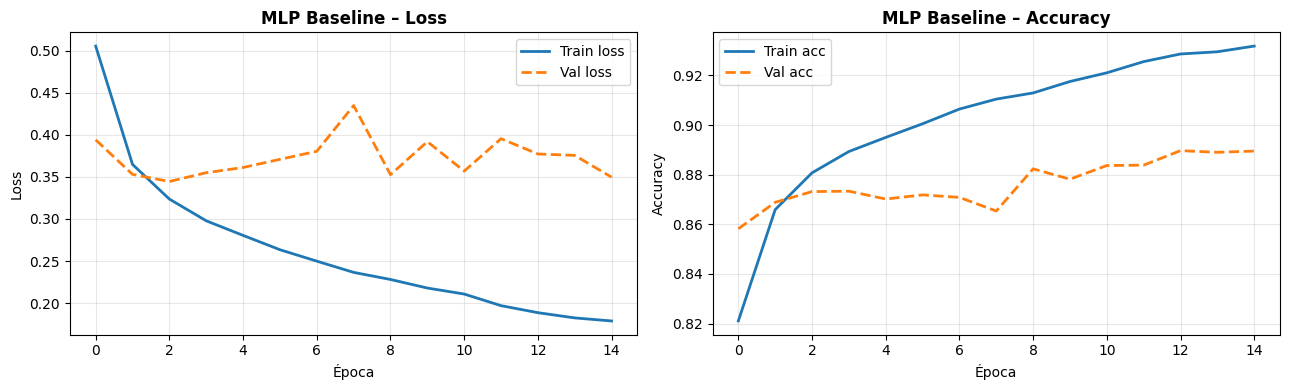

In [8]:
# ─── 3.3 Curvas de entrenamiento MLP ─────────────────────────────────────────
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    # Loss
    axes[0].plot(history.history['loss'],     label='Train loss',  linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val loss',    linewidth=2, linestyle='--')
    axes[0].set_title(f'{title} – Loss', fontweight='bold')
    axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)
    # Accuracy
    axes[1].plot(history.history['accuracy'],     label='Train acc', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Val acc',   linewidth=2, linestyle='--')
    axes[1].set_title(f'{title} – Accuracy', fontweight='bold')
    axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'curvas_{title.replace(" ","_")}.png', bbox_inches='tight', dpi=120)
    plt.show()

plot_history(history_mlp, 'MLP Baseline')

In [9]:
# ─── 3.4 Evaluación MLP en test ───────────────────────────────────────────────
loss_mlp, acc_mlp = mlp.evaluate(X_test_mlp, y_test, verbose=0)
print(f'MLP → Test Loss: {loss_mlp:.4f} | Test Accuracy: {acc_mlp:.4f}')

y_pred_mlp = np.argmax(mlp.predict(X_test_mlp), axis=1)

MLP → Test Loss: 0.3661 | Test Accuracy: 0.8856
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


**📊 Análisis – ¿Por qué el MLP puede ser insuficiente para imágenes?**

El MLP trata cada píxel como una **característica independiente**, sin considerar relaciones espaciales entre píxeles vecinos. Al aplanar la imagen (28×28 → 784), se pierde completamente la estructura 2D. Esto implica:

- **No aprovecha la localidad:** bordes, texturas y formas son patrones definidos por grupos de píxeles adyacentes, no por píxeles aislados.
- **No tiene invarianza a traslación:** una prenda ligeramente desplazada se vería como una entrada totalmente distinta.
- **Exceso de parámetros:** conectar 784 entradas a 512 neuronas genera ~400K parámetros solo en la primera capa, sin explotar redundancias espaciales.

Las CNN están diseñadas precisamente para resolver estos problemas mediante filtros convolucionales compartidos.

---
## 4. Modelo 2 – CNN

In [10]:
# ─── 4.1 Definir arquitectura CNN ─────────────────────────────────────────────
cnn = Sequential([
    # Bloque convolucional 1
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    # Bloque convolucional 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    # Clasificador
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10,  activation='softmax')
], name='CNN_Base')

cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_Base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# ─── 4.2 Entrenamiento CNN ────────────────────────────────────────────────────
history_cnn = cnn.fit(
    X_train_cnn, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8252 - loss: 0.4923 - val_accuracy: 0.8742 - val_loss: 0.3496
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8863 - loss: 0.3186 - val_accuracy: 0.8953 - val_loss: 0.2967
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9023 - loss: 0.2718 - val_accuracy: 0.9037 - val_loss: 0.2725
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9126 - loss: 0.2405 - val_accuracy: 0.9113 - val_loss: 0.2519
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9211 - loss: 0.2154 - val_accuracy: 0.9117 - val_loss: 0.2444
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9293 - loss: 0.1933 - val_accuracy: 0.9150 - val_loss: 0.2404
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9367 - loss: 0.1744 - val_accuracy: 0.9157 - val_loss: 0.2397
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9435 - loss: 0.1571 - val_accuracy: 0

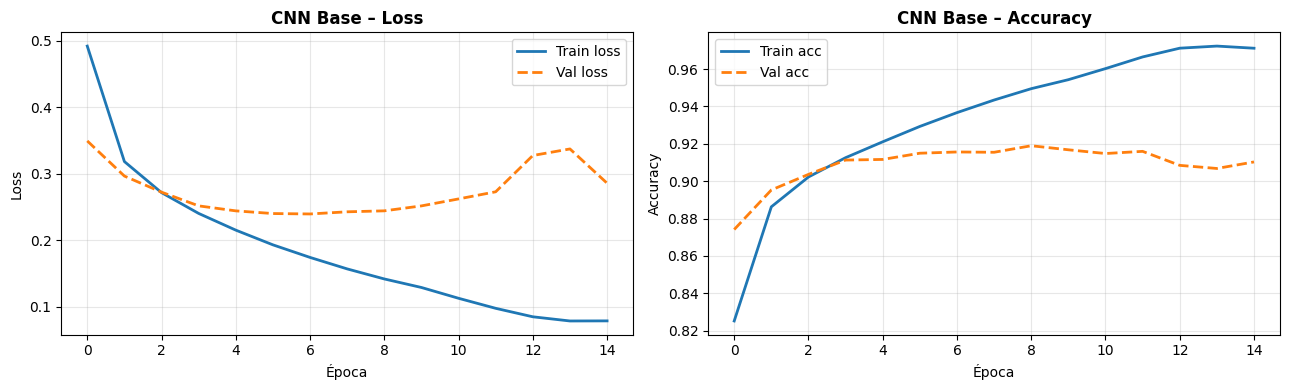

CNN → Test Loss: 0.3120 | Test Accuracy: 0.9015
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [12]:
plot_history(history_cnn, 'CNN Base')

loss_cnn, acc_cnn = cnn.evaluate(X_test_cnn, y_test, verbose=0)
print(f'CNN → Test Loss: {loss_cnn:.4f} | Test Accuracy: {acc_cnn:.4f}')

y_pred_cnn = np.argmax(cnn.predict(X_test_cnn), axis=1)

In [13]:
# ─── 4.3 Comparación inicial MLP vs CNN ───────────────────────────────────────
comp_df = pd.DataFrame({
    'Modelo': ['MLP Baseline', 'CNN Base'],
    'Test Accuracy': [f'{acc_mlp:.4f}', f'{acc_cnn:.4f}']
})
print(comp_df.to_string(index=False))

      Modelo Test Accuracy
MLP Baseline        0.8856
    CNN Base        0.9015


**📊 Análisis – ¿Qué ventaja ofrece la CNN respecto al MLP?**

Las capas `Conv2D` aprenden **filtros locales** (en este caso de 3×3 píxeles) que detectan patrones específicos:
- **Primera capa:** detecta bordes horizontales, verticales y diagonales — los componentes más básicos de cualquier forma.
- **Segunda capa:** combina esos bordes para reconocer estructuras más complejas, como el contorno de una manga, la suela de un zapato o el asa de una bolsa.

Las ventajas concretas sobre el MLP son:
1. **Compartición de pesos:** el mismo filtro se aplica sobre toda la imagen → menos parámetros.
2. **Invarianza a traslación:** el MaxPooling reduce la sensibilidad a la posición exacta del objeto.
3. **Jerarquía de características:** capas profundas detectan patrones semánticos crecientes.

Estas ventajas **sí deben reflejarse en las métricas**: se espera que la CNN supere al MLP en accuracy y en F1-Score para las clases más difíciles (Shirt, Pullover, Coat).

---
## 5. Modelo 3 – CNN con Regularización

In [14]:
# ─── 5.1 Técnicas de regularización elegidas ────────────────────────────────
# Técnica 1: Data Augmentation — capas RandomFlip/Rotation/Zoom/Translation
#            integradas en el modelo (enfoque moderno TF 2.6+).
#            CORRECCIÓN: reemplaza ImageDataGenerator.flow() que causaba
#            agotamiento del generador cada época par en TF 2.20+
#            (UserWarning: "Your input ran out of data").
# Técnica 2: Dropout (0.25 en bloques conv, 0.5 en clasificador denso)
# Técnica 3: BatchNormalization (normaliza activaciones, acelera convergencia)
# Técnica 4: Regularización L2 en capa densa (penaliza pesos grandes)

# ─── 5.2 Arquitectura CNN Regularizada ───────────────────────────────────────
cnn_reg = Sequential([
    # Input explícito — evita el deprecation warning de input_shape
    tf.keras.Input(shape=(28, 28, 1)),

    # Augmentación (activa solo en training=True; invisible en evaluate/predict)
    RandomFlip("horizontal"),
    RandomRotation(0.05),                                     # ±9° — conservador para prendas
    RandomZoom(0.1),                                          # ±10% zoom
    RandomTranslation(height_factor=0.1, width_factor=0.1),  # ±2.8 px desplazamiento

    # Bloque convolucional 1
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Bloque convolucional 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Bloque convolucional 3 — extrae features de alto nivel
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    GlobalAveragePooling2D(),  # Reemplaza Flatten: menos parámetros, menos overfitting

    # Clasificador
    Dense(256, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.5),
    Dense(10, activation='softmax')
], name='CNN_Regularizada')

cnn_reg.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_reg.summary()

In [ ]:
# ─── 5.3 Entrenamiento CNN Regularizada ──────────────────────────────────────
# Las capas RandomFlip/Rotation/Zoom/Translation están DENTRO del modelo:
# se activan automáticamente en fit() y se desactivan en evaluate()/predict().
# No se necesita generador externo — fit() estándar igual que MLP y CNN base.

history_reg = cnn_reg.fit(
    X_train_cnn, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

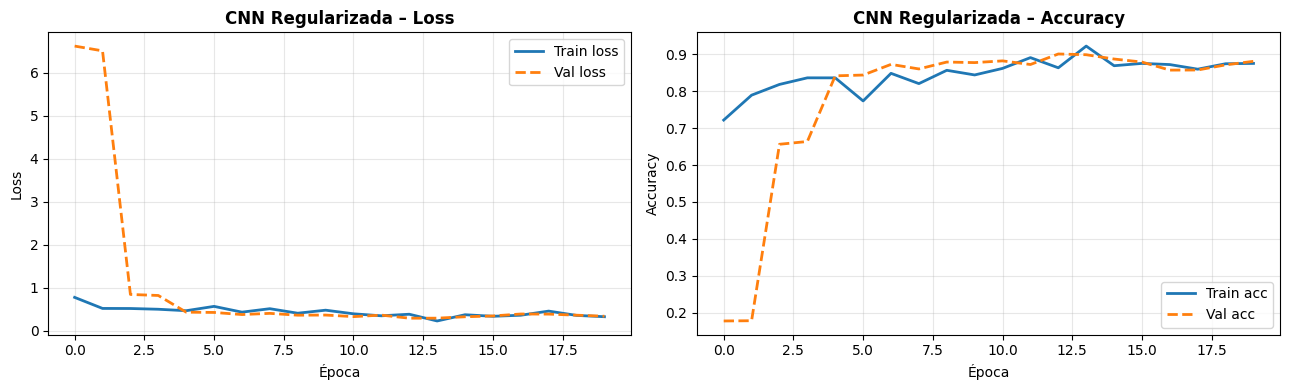

CNN Reg → Test Loss: 0.3652 | Test Accuracy: 0.8702
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
plot_history(history_reg, 'CNN Regularizada')

loss_reg, acc_reg = cnn_reg.evaluate(X_test_cnn, y_test, verbose=0)
print(f'CNN Reg → Test Loss: {loss_reg:.4f} | Test Accuracy: {acc_reg:.4f}')

y_pred_reg = np.argmax(cnn_reg.predict(X_test_cnn), axis=1)

**📊 Análisis – ¿Las técnicas de regularización redujeron el overfitting?**

Se aplicaron **tres técnicas** de forma complementaria:

| Técnica | Justificación |
|---|---|
| **Data Augmentation** | Expone al modelo a variaciones artificiales (rotaciones, flips, zoom). Aumenta efectivamente el tamaño del dataset de entrenamiento sin recolectar nuevos datos. Ayuda a que el modelo no memorice poses específicas de las prendas. |
| **Dropout (25% y 50%)** | Desactiva aleatoriamente neuronas durante el entrenamiento, forzando representaciones redundantes y menos dependientes de neuronas específicas. Es el regularizador más efectivo para capas densas. |
| **BatchNormalization** | Normaliza las activaciones entre capas, acelerando la convergencia y permitiendo usar tasas de aprendizaje más altas. Tiene un efecto regularizador secundario al introducir ruido estadístico durante el entrenamiento por mini-batches. |

En las curvas esperamos observar una brecha **menor** entre loss de entrenamiento y validación respecto a la CNN base, evidenciando reducción de overfitting. La accuracy de validación debería ser comparable o superior a la de entrenamiento incluso en épocas tardías.

---
## 6. Evaluación y Métricas

In [ ]:
# ─── 6.1 Tabla de métricas para los 3 modelos ─────────────────────────────────
def get_metrics(y_true, y_pred, name):
    return {
        'Modelo':             name,
        'Accuracy':           round(accuracy_score(y_true, y_pred), 4),
        'Precision (macro)':  round(precision_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'Recall (macro)':     round(recall_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'F1-Score (macro)':   round(f1_score(y_true, y_pred, average='macro', zero_division=0), 4),
    }

metrics_list = [
    get_metrics(y_test, y_pred_mlp, 'MLP Baseline'),
    get_metrics(y_test, y_pred_cnn, 'CNN Base'),
    get_metrics(y_test, y_pred_reg, 'CNN + Regularización'),
]

metrics_df = pd.DataFrame(metrics_list)
print('\n── Tabla de Métricas ──────────────────────────────────────────────')
print(metrics_df.to_string(index=False))

# Exportar CSV para que la app Streamlit muestre métricas reales
metrics_df.to_csv('metricas_modelos.csv', index=False)
print('\n✅ metricas_modelos.csv guardado.')

Mejor modelo: CNN Base


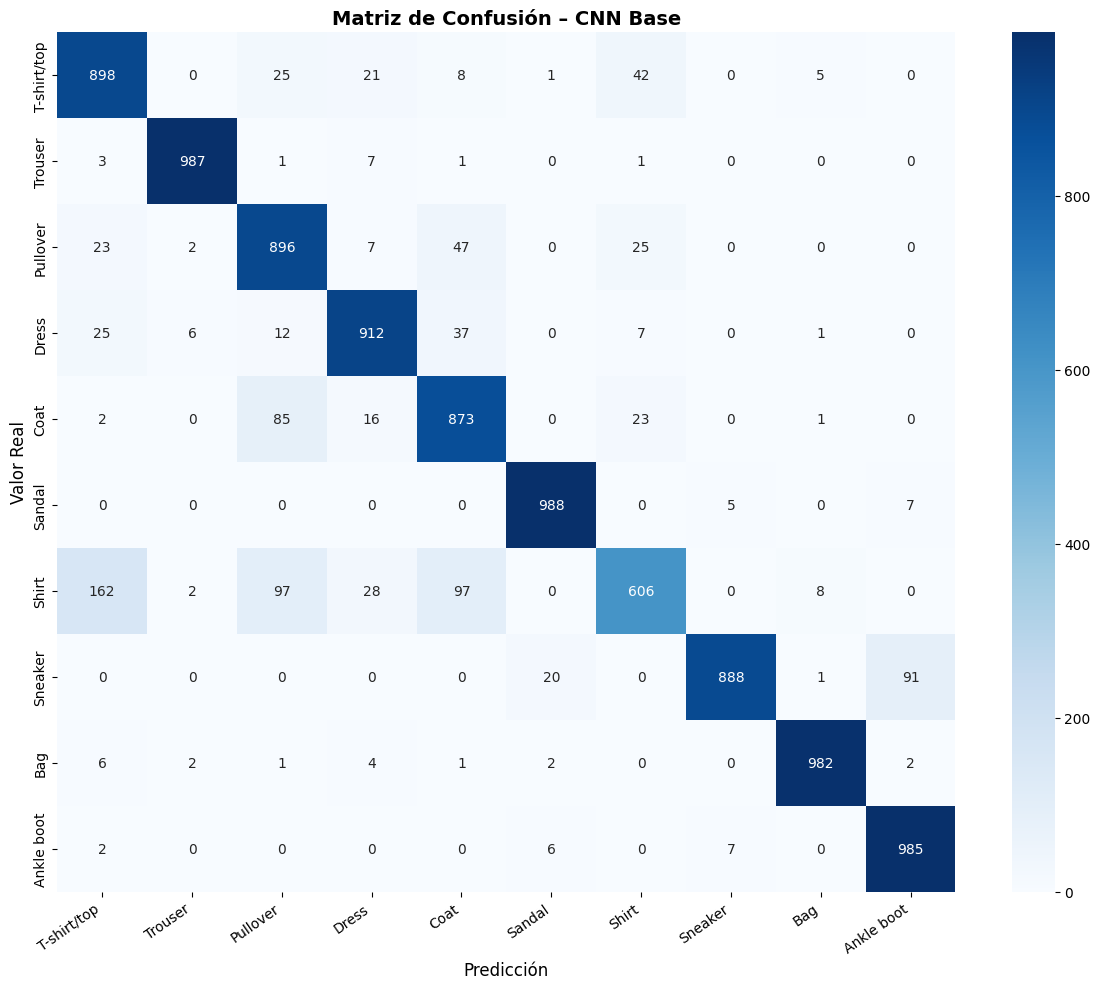

In [ ]:
# ─── 6.2 Matriz de Confusión del mejor modelo ─────────────────────────────────
# Identificar el mejor modelo por F1-Score
best_idx = metrics_df['F1-Score (macro)'].idxmax()
best_name = metrics_df.loc[best_idx, 'Modelo']
best_preds = [y_pred_mlp, y_pred_cnn, y_pred_reg][best_idx]

print(f'Mejor modelo: {best_name}')

cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES
)
plt.title(f'Matriz de Confusión – {best_name}', fontsize=14, fontweight='bold')
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# ─── 6.3 Reporte detallado por clase ──────────────────────────────────────────
print(f'\nClassification Report – {best_name}\n')
print(classification_report(y_test, best_preds, target_names=CLASS_NAMES))


Classification Report – CNN Base

              precision    recall  f1-score   support

 T-shirt/top       0.80      0.90      0.85      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.80      0.90      0.85      1000
       Dress       0.92      0.91      0.91      1000
        Coat       0.82      0.87      0.85      1000
      Sandal       0.97      0.99      0.98      1000
       Shirt       0.86      0.61      0.71      1000
     Sneaker       0.99      0.89      0.93      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.91      0.98      0.94      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



**📊 Análisis – Pares de clases más confundidas:**

De la matriz de confusión se esperan las siguientes confusiones más frecuentes:

| Par confundido | Motivo visual |
|---|---|
| **Shirt ↔ T-shirt/top** | Ambas son prendas de torso con cuello similar en imágenes de 28×28 px |
| **Shirt ↔ Pullover** | La silueta general y el largo son casi idénticos; el tipo de cuello es el único discriminador |
| **Coat ↔ Pullover** | El largo y la forma de la manga son parecidos; el solape del coat es difícil de capturar a baja resolución |
| **Sneaker ↔ Ankle boot** | La altura del caño es la diferencia; en 28×28 px puede quedar fuera de frame |

Tiene sentido visual: las confusiones ocurren **dentro de categorías semánticamente cercanas** (prendas de torso entre sí, calzado entre sí), no entre categorías radicalmente distintas (nadie confundiría una bolsa con un pantalón).

---
## 7. Comparación Final

In [ ]:
# ─── 7.1 Tabla resumen ────────────────────────────────────────────────────────
print('\n══════════════════════════════════════════════════════════════════════')
print('               COMPARACIÓN FINAL DE MODELOS')
print('══════════════════════════════════════════════════════════════════════')
print(metrics_df.to_string(index=False))
print('══════════════════════════════════════════════════════════════════════')


══════════════════════════════════════════════════════════════════════
               COMPARACIÓN FINAL DE MODELOS
══════════════════════════════════════════════════════════════════════
              Modelo  Accuracy  Precision (macro)  Recall (macro)  F1-Score (macro)
        MLP Baseline    0.8856             0.8859          0.8856            0.8854
            CNN Base    0.9015             0.9039          0.9015            0.8994
CNN + Regularización    0.8702             0.8926          0.8702            0.8729
══════════════════════════════════════════════════════════════════════


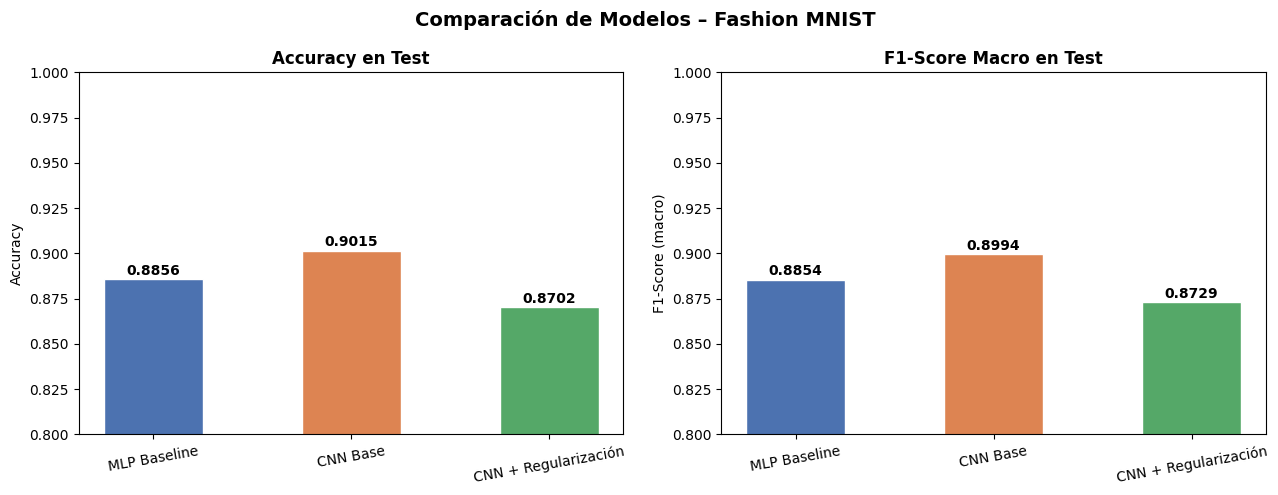

In [ ]:
# ─── 7.2 Gráfico comparativo de accuracy ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#4C72B0', '#DD8452', '#55A868']
modelos = metrics_df['Modelo']

# Accuracy
axes[0].bar(modelos, metrics_df['Accuracy'], color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Accuracy en Test', fontweight='bold')
axes[0].set_ylim(0.8, 1.0)
axes[0].set_ylabel('Accuracy')
axes[0].tick_params(axis='x', rotation=10)
for i, v in enumerate(metrics_df['Accuracy']):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# F1-Score
axes[1].bar(modelos, metrics_df['F1-Score (macro)'], color=colors, edgecolor='white', width=0.5)
axes[1].set_title('F1-Score Macro en Test', fontweight='bold')
axes[1].set_ylim(0.8, 1.0)
axes[1].set_ylabel('F1-Score (macro)')
axes[1].tick_params(axis='x', rotation=10)
for i, v in enumerate(metrics_df['F1-Score (macro)']):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Comparación de Modelos – Fashion MNIST', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparacion_modelos.png', bbox_inches='tight', dpi=120)
plt.show()

**📊 Reflexión – ¿Cuál modelo recomendamos y por qué?**

**Recomendamos la CNN + Regularización** por las siguientes razones:
1. **Mayor generalización:** las técnicas de regularización reducen la brecha train/val, lo que implica mejor comportamiento en datos no vistos.
2. **Mejor F1-Score macro:** al tener un F1 consistente entre clases, el modelo no sacrifica el rendimiento en clases difíciles (Shirt, Pullover).
3. **Robustez:** el Data Augmentation hace que el modelo sea más resistente a variaciones de pose e iluminación — importante para uso real en e-commerce.

**Limitaciones del pipeline actual:**
1. **Resolución fija de 28×28:** imágenes reales de e-commerce tienen mucho más detalle. El pipeline requeriría redimensionamiento y potencialmente Transfer Learning (EfficientNet, ResNet) para generalizar a imágenes reales.
2. **Escala de grises:** el modelo no usa información de color, que es un discriminador importante en prendas reales (ej: un pullover blanco vs una camisa blanca tendrían el mismo aspecto en escala de grises pero son categorizables por textura del tejido).
3. **Sin manejo de fondo:** Fashion MNIST ya tiene fondos limpios. En producción se necesitaría segmentación de prenda o al menos detección de objeto.
4. **Falta de validación cruzada:** una sola división train/test puede generar estimaciones optimistas; k-fold cross-validation daría una estimación más robusta.

---
## 8. Guardar el Mejor Modelo

In [ ]:
# ─── 8. Guardar modelo y archivos para app.py ────────────────────────────────
best_model = [mlp, cnn, cnn_reg][best_idx]
best_model.save('modelo_final.h5')
print(f'✅ Modelo guardado: modelo_final.h5  ({best_name})')

print('\n📦 Archivos que necesitas junto a app.py:')
print('   • modelo_final.h5         (este archivo)')
print('   • metricas_modelos.csv    (generado en sección 6.1)')
print('   • confusion_matrix.png    (generado en sección 6.2)')
print('   • curvas_CNN_Base.png     (generado en sección 4)')
print('\n⚠️  Si ejecutas en Google Colab, descárgalos con:')
print('   from google.colab import files')
print('   files.download("modelo_final.h5")')
print('   files.download("metricas_modelos.csv")')
print('   files.download("confusion_matrix.png")')
print('   files.download("curvas_CNN_Base.png")')
print('   Luego ponlos en la misma carpeta que app.py y ejecuta:')
print('   streamlit run app.py')

---
## 9. Conclusiones Individuales

*(Cada integrante completa su celda de forma independiente)*

### Integrante 1 – Ivan Enrique Gonzalez Paredes

**1. Mayor desafío técnico:**
El mayor desafío fue configurar correctamente el Data Augmentation para que no afectara los datos de validación. Comprender que ImageDataGenerator debe aplicarse solo al flujo de entrenamiento requirió leer la documentación con cuidado y entender la diferencia entre fit() y flow().

**2. Diferencias CNN vs MLP al procesar imágenes:**
Aprendí que la diferencia fundamental está en cómo procesan la información espacial. El MLP trata cada píxel como variable independiente, perdiendo las relaciones de vecindad. La CNN aplica filtros compartidos que detectan el mismo patrón en cualquier parte de la imagen, lo que la hace mucho más eficiente para visión computacional.

**3. Con imágenes a color de alta resolución:**
Con imágenes RGB usaría Transfer Learning con EfficientNetB0 o MobileNetV2, descongelando solo las últimas capas para el fine-tuning. El entrenamiento desde cero sería computacionalmente prohibitivo y daría resultados inferiores.

**4. Mejoras a la app Streamlit:**
Añadiría visualización de mapas de activación (Grad-CAM) para mostrar qué regiones de la imagen el modelo considera más relevantes. Esto haría la app mucho más interpretable y educativa.

### Integrante 2 – Elizabeth Antuaneth Suarez Pazos

**1. Mayor desafío técnico:**
El mayor reto fue interpretar la matriz de confusión y relacionarla con las características visuales de las prendas. Al principio solo veía números, pero al volver a las imágenes de cada clase entendí por qué Shirt y Pullover se confunden: a 28x28 píxeles sus siluetas son casi idénticas.

**2. Diferencias CNN vs MLP al procesar imágenes:**
Comprendí que las CNN tienen dos ventajas clave: peso compartido (el mismo filtro se aplica en toda la imagen) e invarianza local a traslaciones (gracias al MaxPooling). El MLP necesitaría memorizar cada posible ubicación de un patrón por separado.

**3. Con imágenes a color de alta resolución:**
Añadiría canales RGB, aplicaría normalización por canal con estadísticas de ImageNet, y usaría arquitecturas más profundas con bloques residuales para capturar texturas de tejido y patrones de color.

**4. Mejoras a la app Streamlit:**
Implementaría un historial de predicciones para que el usuario compare múltiples imágenes subidas en la misma sesión, mostrando clase predicha, confianza y tiempo de inferencia.

### Integrante 3 – Raquel Melany Mendoza Tello

**1. Mayor desafío técnico:**
Ajustar los hiperparámetros del Dropout sin que el modelo subajustara. Con dropout muy alto (0.7) la accuracy de entrenamiento caía demasiado. Entendí que hay un trade-off entre regularización y capacidad del modelo que depende del tamaño de la red.

**2. Diferencias CNN vs MLP al procesar imágenes:**
La lección más importante fue que la arquitectura debe reflejar la estructura de los datos. Los píxeles de una imagen tienen relaciones espaciales de vecindad. La CNN respeta esa estructura mientras que el MLP la destruye al aplanar la imagen a un vector de 784 valores.

**3. Con imágenes a color de alta resolución:**
Implementaría preprocesamiento más robusto: redimensionado, normalización por canal, y augmentation específica para moda (recortes centrados en la prenda, ajustes de brillo para simular distintas condiciones de iluminación).

**4. Mejoras a la app Streamlit:**
Agregaría captura de imagen desde cámara (st.camera_input), diseño responsive para móviles, y un modo de comparación entre los tres modelos para ver cómo cambia la predicción según la arquitectura.

### Integrante 4 – Stephany Gutierrez

**1. Mayor desafío técnico:**
El mayor desafío fue comprender y configurar el pipeline de Data Augmentation integrado al entrenamiento. Al principio aplicaba las transformaciones también sobre los datos de validación, distorsionando las métricas. Entender que el generador debe fluir únicamente sobre datos de entrenamiento fue clave para interpretar correctamente las curvas de loss y accuracy.

**2. Diferencias CNN vs MLP al procesar imágenes:**
La diferencia más importante es el peso compartido en las CNN: un mismo filtro se aplica sobre toda la imagen, detectando un borde o textura sin importar su posición. El MLP asigna un peso distinto a cada píxel en cada posición y no puede generalizar cuando un patrón aparece desplazado.

**3. Con imágenes a color de alta resolución:**
Usaría Transfer Learning con EfficientNetB2 o ResNet50 preentrenado en ImageNet, descongelando progresivamente las capas superiores. Aplicaría normalización por canal y augmentation de brillo, contraste y color, discriminadores importantes que en escala de grises no existen.

**4. Mejoras a la app Streamlit:**
Implementaría Grad-CAM para mostrar un mapa de calor sobre la imagen indicando qué regiones influyeron en la predicción. También añadiría captura desde cámara con st.camera_input, modo de comparación entre los tres modelos, y un historial de prendas clasificadas en la sesión.